In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('sustainability_data.csv')

In [3]:
X = data[['Energy_Consumption', 'Renewable_Percentage', 'GDP']]
y = data['CO2_Emissions']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

In [5]:
model = LinearRegression()
model.fit(X_poly_train, y_train)

LinearRegression()

In [7]:
y_pred = model.predict(X_poly_test)

In [8]:
y_pred

array([ 734.07298491,  874.62164867,  947.22015401,  858.08950479,
       1027.78382866])

In [9]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R² Score: {r2}')

Mean Squared Error: 2341.1134159353965
R² Score: 0.06978468406875404


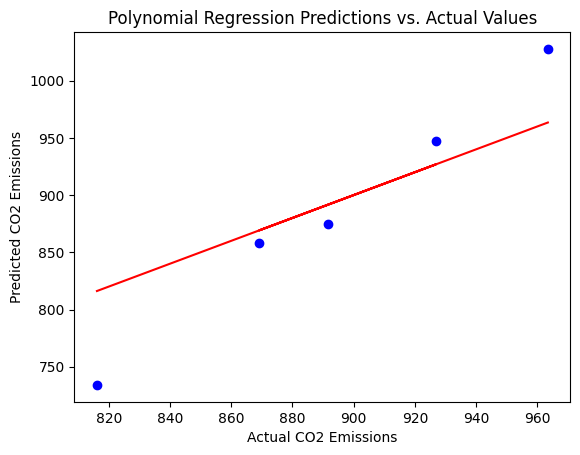

In [10]:
plt.scatter(y_test, y_pred, color='blue')
plt.plot(y_test, y_test, color='red')  # 45-degree line
plt.xlabel('Actual CO2 Emissions')
plt.ylabel('Predicted CO2 Emissions')
plt.title('Polynomial Regression Predictions vs. Actual Values')
plt.show()

In [11]:
import joblib
joblib.dump(model, 'polynomialRegModel.pkl')

['polynomialRegModel.pkl']

In [12]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import PolynomialFeatures

# Page configuration
st.set_page_config(page_title="Sustainability & CO2 Emissions Predictor", page_icon="🌱", layout="centered")

@st.cache_resource
def load_model():
    return joblib.load("polynomialRegModel.pkl")

@st.cache_data
def load_data():
    return pd.read_csv("sustainability_data.csv")

try:
    model = load_model()
    df = load_data()
    model_loaded = True
except Exception as e:
    model_loaded = False
    st.error(f"Error loading model or dataset: {e}")

st.title("🌱 CO₂ Emissions Predictor")
st.write("Estimate total **CO₂ Emissions** based on key energy and economic indicators.")

if model_loaded:
    st.subheader("Input Indicators")

    # Input sliders/fields with default values based on dataset averages
    energy = st.number_input(
        "Energy Consumption",
        min_value=0.0,
        max_value=2000.0,
        value=float(df["Energy_Consumption"].mean()),
        step=5.0
    )

    renewable = st.number_input(
        "Renewable Energy Percentage (%)",
        min_value=0.0,
        max_value=100.0,
        value=float(df["Renewable_Percentage"].mean()),
        step=0.5
    )

    gdp = st.number_input(
        "GDP",
        min_value=0.0,
        max_value=10000.0,
        value=float(df["GDP"].mean()),
        step=50.0
    )

    if st.button("Predict CO₂ Emissions"):
        # Apply Polynomial Transformation (Degree 2, include_bias=True)
        raw_input = np.array([[energy, renewable, gdp]])
        poly = PolynomialFeatures(degree=2, include_bias=True)
        transformed_input = poly.fit_transform(raw_input)

        # Predict target
        prediction = model.predict(transformed_input)[0]

        st.markdown("---")
        st.metric(label="Predicted CO₂ Emissions", value=f"{prediction:.2f}")

    # Dataset preview section
    with st.expander("View Historical Sustainability Data"):
        st.dataframe(df)

Writing app.py


In [13]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
joblib

Writing requirements.txt
